Quick script for looking at VTA opto stim effect

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [118]:
base_path = r"Z:\FNT_Dotchasing"
mouse = "JasmineDATCRE2"
session = "2026-09-03T08-39-23"
fig_save_path = os.path.join(base_path, mouse, session, "Figures")
os.makedirs(fig_save_path, exist_ok=True)
cam_path = os.path.join(base_path, mouse, session, "WebVideo", session + "_video.avi")
mouse_location_path = os.path.join(base_path, mouse, session, "WebVideo", session + "_video_tracking.csv")
dot_info_path = os.path.join(base_path, mouse, session, "Experimental-data", session + "_experimental-data.csv")
mouse_location = pd.read_csv(mouse_location_path)
dot_info = pd.read_csv(dot_info_path)

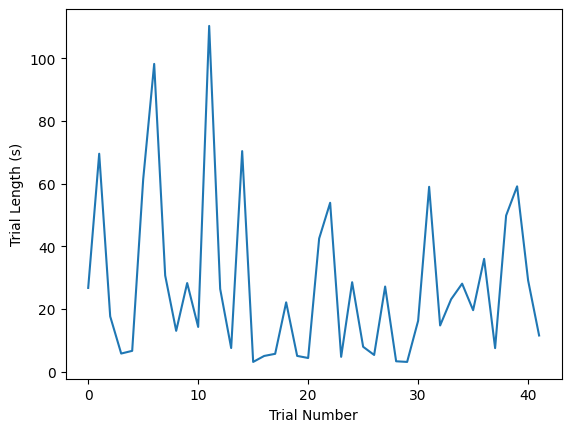

In [119]:
"""Trial length over the session"""
# this is how long the dot was present. The dot disappears once the mouse has been on it for 1s.
trial_length = dot_info['TrialEnd'].to_numpy() - dot_info['TrialStart'].to_numpy()
plt.plot(trial_length)
plt.xlabel('Trial Number')
plt.ylabel('Trial Length (s)')
plt.savefig(os.path.join(fig_save_path, 'trial_length_over_session.png'))

Text(0, 0.5, 'Mean Distance to Dot (norm a.u.)')

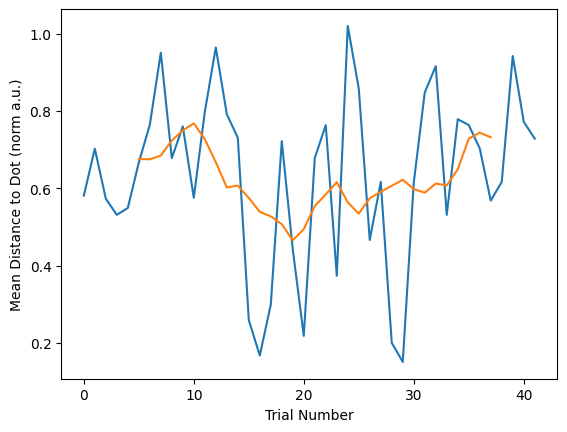

In [120]:
"""Mean distance of mouse to dot on each trial"""
mean_dot_distance = np.empty(len(dot_info))
# check how many frames are in each trial to make sure the array is big enough
time_points = np.empty(len(dot_info))
for trial in range(len(dot_info)):
    trial_start = dot_info['TrialStart'][trial]
    trial_end = dot_info['TrialEnd'][trial]
    trial_data = mouse_location[(mouse_location['Seconds'] >= trial_start) & (mouse_location['Seconds'] <= trial_end)]
    time_points[trial] = len(trial_data)
trial_dot_distance = np.full((int(max(time_points)), len(dot_info)), np.nan)
# iterate over trials and calculate the distance of the mouse to the dot for each time point in the trial
for trial in range(len(dot_info)):
    trial_start = dot_info['TrialStart'][trial]
    trial_end = dot_info['TrialEnd'][trial]
    trial_data = mouse_location[(mouse_location['Seconds'] >= trial_start) & (mouse_location['Seconds'] <= trial_end)]
    for i in range(len(trial_data)):
        x1, y1 = trial_data.iloc[i]['Value.X'], trial_data.iloc[i]['Value.Y']
        trial_dot_distance[i, trial] = ((x1 - dot_info['DotXLocation'][trial])**2 + (y1 - dot_info['DotYLocation'][trial])**2)**0.5
    mean_dot_distance[trial] = np.nanmean(trial_dot_distance[:, trial])
plt.plot(mean_dot_distance)
# plot the moving mean of the mean distance to the dot with a window size of 10 trials
window_size = 10
xpoints = np.arange(len(mean_dot_distance) - window_size + 1) + window_size // 2
moving_mean = np.convolve(mean_dot_distance, np.ones(window_size)/window_size, mode='valid')
plt.plot(xpoints, moving_mean)
plt.xlabel('Trial Number')
plt.ylabel('Mean Distance to Dot (norm a.u.)')

In [121]:
"""Probability of stopping on the dot over time"""
distance = np.full(len(mouse_location), np.nan)
fake_distance = np.full(len(mouse_location), np.nan)
for i in range(len(mouse_location)):
    x1, y1 = mouse_location.iloc[i]['Value.X'], mouse_location.iloc[i]['Value.Y']
    s = mouse_location.iloc[i]['Seconds']
    which_trial = np.where((dot_info['TrialStart'] <= s) & (dot_info['TrialEnd'] >= s))[0]
    if len(which_trial) > 0:
        trial = which_trial[0]
        distance[i] = ((x1 - dot_info['DotXLocation'][trial])**2 + (y1 - dot_info['DotYLocation'][trial])**2)**0.5
        trial = np.random.randint(0, len(dot_info))
        fake_distance[i] = ((x1 - dot_info['DotXLocation'][trial])**2 + (y1 - dot_info['DotYLocation'][trial])**2)**0.5

In [122]:
"""Compute speed"""
# 1) Smooth positions to reduce high-frequency jitter
# Use a rolling median or moving average; odd window is easiest
window = 10  # ~0.2 s at 50 fps
x_smooth = pd.Series(mouse_location['Value.X']).rolling(window, center=True, min_periods=1).median().to_numpy()
y_smooth = pd.Series(mouse_location['Value.Y']).rolling(window, center=True, min_periods=1).median().to_numpy()

# 2) Differentiate the smoothed position to get velocity
vx = np.gradient(x_smooth, mouse_location['Seconds'].to_numpy(dtype=float), edge_order=1)
vy = np.gradient(y_smooth, mouse_location['Seconds'].to_numpy(dtype=float), edge_order=1)

# 3) Speed magnitude
speed = np.hypot(vx, vy)

# 4) Optional extra smoothing on speed itself
speed = pd.Series(speed).rolling(5, center=True, min_periods=1).median().to_numpy()

# acceleration = change in speed over time
accel = np.gradient(speed, mouse_location['Seconds'].to_numpy(dtype=float), edge_order=1)

# deceleration is only negative acceleration
decel = np.clip(-accel, 0, None)

c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:1245: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:1246: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packa

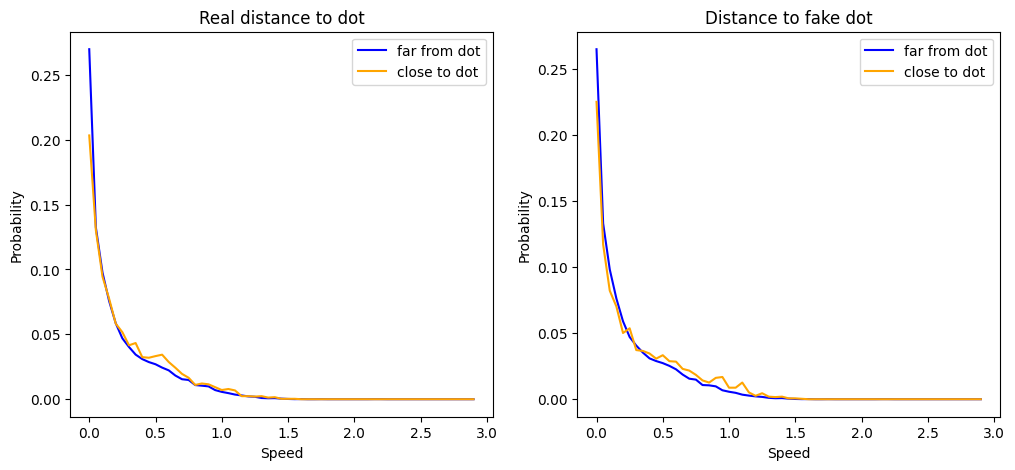

In [123]:
"""Speed distribution for close vs far from dot"""
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
h = np.histogram(speed[distance > .22], bins=np.arange(0, 3, 0.05))
h2 = np.histogram(speed[distance <= .22], bins=np.arange(0, 3, 0.05))
axs[0].plot(h[1][:-1], h[0]/np.sum(h[0]), label='far from dot', color='blue')
axs[0].plot(h2[1][:-1], h2[0]/np.sum(h2[0]), label='close to dot', color='orange')
axs[0].legend()
axs[0].set_xlabel("Speed")
axs[0].set_ylabel("Probability")
axs[0].set_title("Real distance to dot")
h = np.histogram(speed[fake_distance > .22], bins=np.arange(0, 3, 0.05))
h2 = np.histogram(speed[fake_distance <= .22], bins=np.arange(0, 3, 0.05))
axs[1].plot(h[1][:-1], h[0]/np.sum(h[0]), label='far from dot', color='blue')
axs[1].plot(h2[1][:-1], h2[0]/np.sum(h2[0]), label='close to dot', color='orange')
axs[1].legend()
axs[1].set_xlabel("Speed")
axs[1].set_ylabel("Probability")
axs[1].set_title("Distance to fake dot")
fig.savefig(os.path.join(fig_save_path, 'speed_distribution_close_vs_far_from_dot.png'))

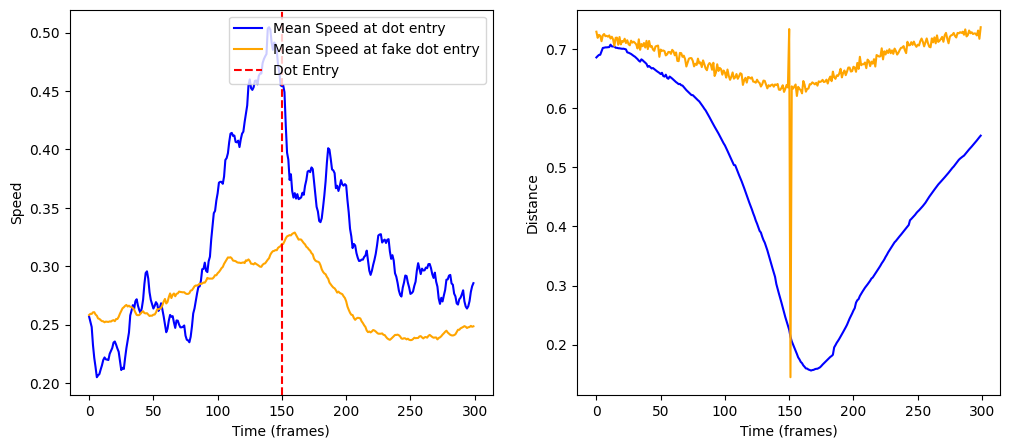

In [124]:
"""Look at speed profile when mouse approaches dot"""
before = 150
after = 150
dot_entering = np.where(np.diff((distance <= .22).astype(int)) == 1)[0]
speed_in_dot = np.full((before + after, len(dot_entering)), np.nan)
distance_in_dot = np.full((before + after, len(dot_entering)), np.nan)
for i, de in enumerate(dot_entering):
    speed_in_dot[:, i] = speed[de-before:de+after]
    distance_in_dot[:, i] = distance[de-before:de+after]
# plt.imshow(speed_in_dot.T, aspect='auto', cmap='viridis')
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(np.nanmean(speed_in_dot, axis=1), color='blue', label='Mean Speed at dot entry')
ax[1].plot(np.nanmean(distance_in_dot, axis=1), color='blue', label='Mean Distance at dot entry')
dot_entering = np.where(np.diff((fake_distance <= .22).astype(int)) == 1)[0]
speed_in_dot = np.full((before + after, len(dot_entering)), np.nan)
distance_in_dot = np.full((before + after, len(dot_entering)), np.nan)
for i, de in enumerate(dot_entering):
    if de-before < 0 or de+after > len(speed):
        continue
    speed_in_dot[:, i] = speed[de-before:de+after]
    distance_in_dot[:, i] = fake_distance[de-before:de+after]
ax[0].plot(np.nanmean(speed_in_dot, axis=1), color='orange', label='Mean Speed at fake dot entry')
ax[1].plot(np.nanmean(distance_in_dot, axis=1), color='orange', label='Mean Distance at fake dot entry')
ax[0].axvline(before, color='red', linestyle='--', label='Dot Entry')
ax[0].set_xlabel("Time (frames)")
ax[0].set_ylabel("Speed")
ax[0].legend()
axs[1].axvline(before, color='red', linestyle='--', label='Dot Entry')
ax[1].set_xlabel("Time (frames)")
ax[1].set_ylabel("Distance")
fig.savefig(os.path.join(fig_save_path, 'speed_and_distance_around_dot_entry.png'))

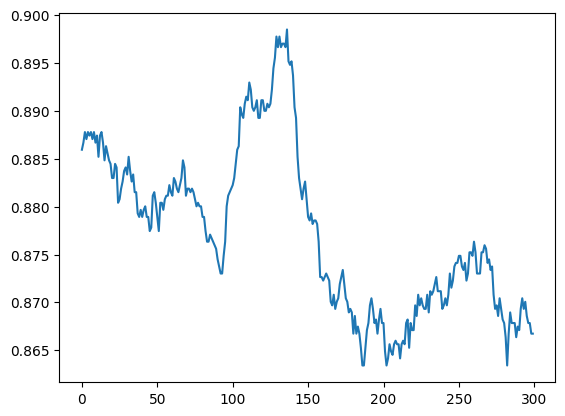

In [94]:
"""Look at decelerations: what is the distance to dot?"""
decel_threshold = -5  # define a threshold for deceleration
decelerations = np.where(np.diff((accel < decel_threshold).astype(int)) == 1)[0]
distance_at_decel = np.full((before + after, len(decelerations)), np.nan)
for i, de in enumerate(decelerations):
    if de-before < 0 or de+after >= len(distance):
        continue
    distance_at_decel[:, i] = distance[de-before:de+after]
plt.plot(np.nanmean(distance_at_decel>.22, axis=1))
# plt.imshow(((distance_at_decel.T)>.22).astype(int), aspect='auto', cmap='viridis', vmin=0, vmax=1)
# plt.

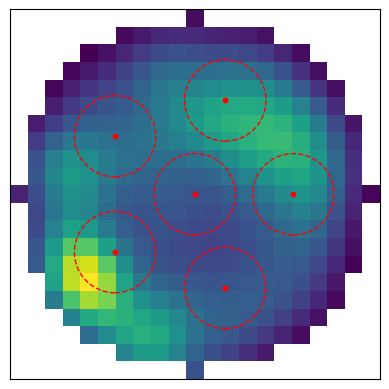

In [125]:
"""Whole arena spatial occupancy map"""
bin_size = .1
arena_radius = 1
nbins = int((arena_radius*2) / bin_size)
one_sided_bins = np.arange(0, arena_radius + bin_size, bin_size)
bins = np.concatenate((-one_sided_bins[::-1], one_sided_bins[1:]))
x_bins = pd.cut(mouse_location['Value.X'], bins=bins, labels=False, retbins=False)
y_bins = pd.cut(mouse_location['Value.Y'], bins=bins, labels=False, retbins=False)

from scipy.ndimage import gaussian_filter

fps = 40  # set to your video frame rate
sigma = 1.5  # smoothing in bins

# attach bin labels to the dataframe
df = mouse_location.copy()
df["xbins"] = x_bins
df["ybins"] = y_bins

# keep only frames that landed in a valid bin
df = df.dropna(subset=["xbins", "ybins"]).copy()
df["xbins"] = df["xbins"].astype(int)
df["ybins"] = df["ybins"].astype(int)

nbins = len(one_sided_bins) * 2 - 1

# count frames per bin, then convert to seconds
occ = (
    df.groupby(["ybins", "xbins"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=range(nbins), columns=range(nbins), fill_value=0)
      .to_numpy(dtype=float)
)
occ_seconds = occ / fps

# optional circular arena mask
yy, xx = np.indices(occ_seconds.shape)
center = (nbins - 1) / 2
radius_bins = (arena_radius / bin_size)
circular_mask = (xx - center) ** 2 + (yy - center) ** 2 <= radius_bins ** 2
occ_seconds[~circular_mask] = np.nan

# smooth while preserving NaN mask
nan_mask = np.isnan(occ_seconds)
occ_filled = np.nan_to_num(occ_seconds, nan=0.0)
occ_smooth = gaussian_filter(occ_filled, sigma=sigma)
occ_smooth[nan_mask] = np.nan

plt.imshow(occ_smooth, origin="lower", extent=(-arena_radius, arena_radius, -arena_radius, arena_radius), cmap="viridis")
unique_dots = dot_info[['DotXLocation', 'DotYLocation']].drop_duplicates()
for i, row in unique_dots.iterrows():
    plt.scatter(row['DotXLocation'], row['DotYLocation'], color='red', s=10, label='Dot Locations')
    # add a circle around the dot location with radius 0.22
    circle = plt.Circle((row['DotXLocation'], row['DotYLocation']), 0.22, color='red', fill=False, linestyle='--', linewidth=1)
    plt.gca().add_patch(circle)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.savefig(os.path.join(fig_save_path, 'spatial_occupancy_map.png'))

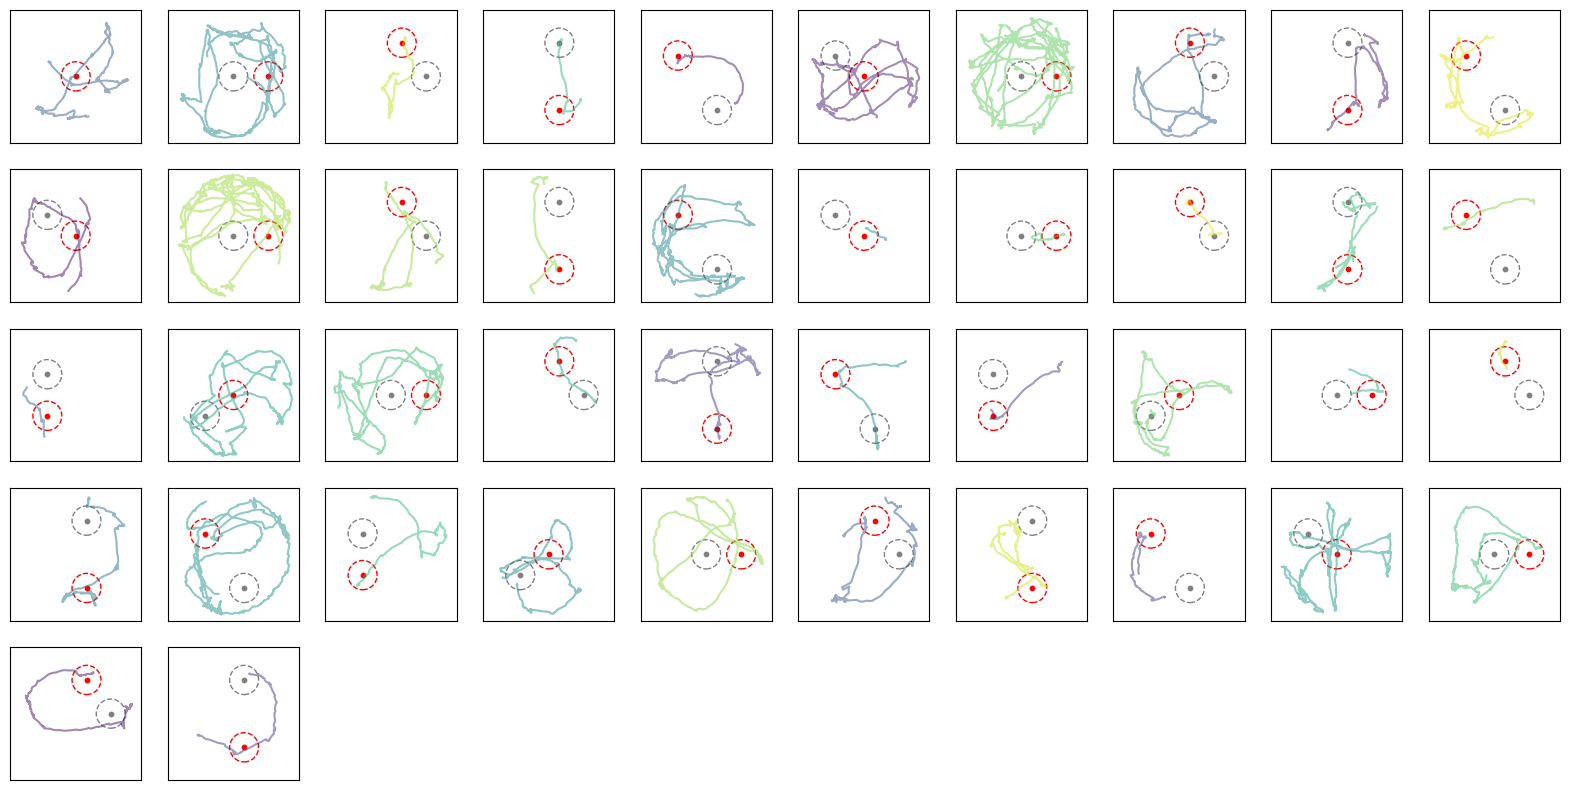

In [129]:
"""Trajectory plot"""
# make color map for number of trials
ntrials = len(dot_info)
cmap = plt.get_cmap('viridis', ntrials)
cols = 10
rows = int(np.ceil(ntrials/cols))
fig, axs = plt.subplots(rows,cols, figsize=(cols*2, rows*2))
for i in range(rows*cols):
    ts = dot_info['TrialStart'].to_numpy()[i] if i < ntrials else None
    te = dot_info['TrialEnd'].to_numpy()[i] if i < ntrials else None
    if ts is None or te is None:
        axs[i//cols, i%cols].axis('off')
        continue
    trial_data = mouse_location[(mouse_location['Seconds'] >= ts) & (mouse_location['Seconds'] <= te)]
    ax = axs[i//cols, i%cols]
    ax.plot(trial_data['Value.X'], trial_data['Value.Y'], color=cmap(np.random.randint(0, ntrials)), alpha=0.5)
    
    if i>0:
        ax.scatter(dot_info['DotXLocation'].to_numpy()[i-1], dot_info['DotYLocation'].to_numpy()[i-1], color='grey', s=10, label='Dot Locations')
        # add a circle around the dot location with radius 0.22
        circle = plt.Circle((dot_info['DotXLocation'].to_numpy()[i-1], dot_info['DotYLocation'].to_numpy()[i-1]), 0.22, color='grey', fill=False, linestyle='--', linewidth=1)
        ax.add_patch(circle)
    ax.scatter(dot_info['DotXLocation'].to_numpy()[i], dot_info['DotYLocation'].to_numpy()[i], color='red', s=10, label='Dot Locations')
    # add a circle around the dot location with radius 0.22
    circle = plt.Circle((dot_info['DotXLocation'].to_numpy()[i], dot_info['DotYLocation'].to_numpy()[i]), 0.22, color='red', fill=False, linestyle='--', linewidth=1)
    ax.add_patch(circle)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim([-1,1])
    ax.set_xlim([-1,1])

plt.savefig(os.path.join(fig_save_path, 'single_trial_trajectory.png'))

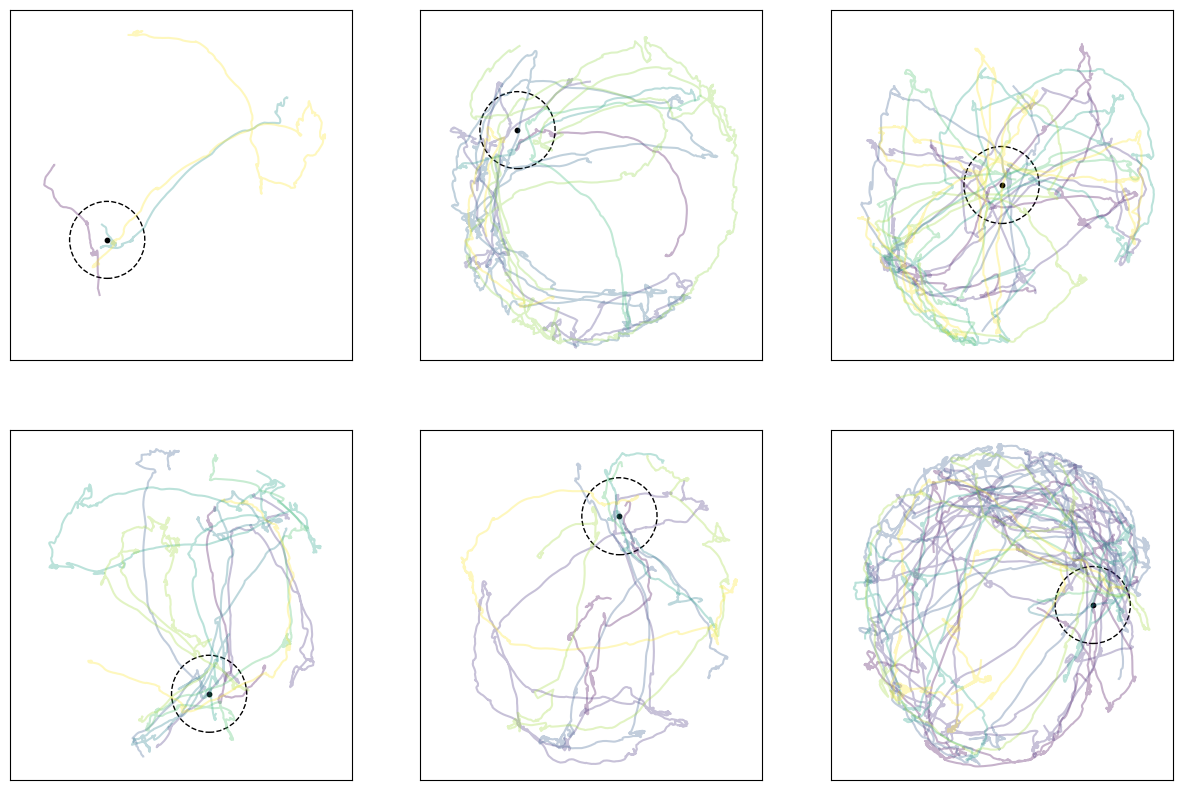

In [128]:
"""Trajectory plot"""
dot_xy = np.vstack([dot_info['DotXLocation'].to_numpy(), dot_info['DotYLocation'].to_numpy()])
dot_start = dot_info['TrialStart'].to_numpy()
dot_end = dot_info['TrialEnd'].to_numpy()
idx, dots = np.unique(dot_xy, axis=1, return_inverse=True)
ndots = len(idx[0])

cols = 3 if ndots > 3 else ndots
rows = int(np.ceil(ndots/cols))
fig, axs = plt.subplots(rows,cols, figsize=(cols*5, rows*5))
for n in range(ndots):
    ntrials = np.where(dots == n)[0]
    cmap = plt.get_cmap('viridis', len(ntrials))
    ax = axs[n//cols, n%cols] if ndots > 3 else axs[n]
    all_ts = dot_start[ntrials]
    all_te = dot_end[ntrials]
    for i, (ts, te) in enumerate(zip(all_ts, all_te)):
        trial_data = mouse_location[(mouse_location['Seconds'] >= ts) & (mouse_location['Seconds'] <= te)]
        ax.plot(trial_data['Value.X'], trial_data['Value.Y'], color=cmap(i), alpha=0.3)
    
    ax.scatter(idx[0, n], idx[1, n], color='black', s=10, label='Dot Locations')
    # add a circle around the dot location with radius 0.22
    circle = plt.Circle((idx[0, n], idx[1, n]), 0.22, color='black', fill=False, linestyle='--', linewidth=1)
    ax.add_patch(circle)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim([-1,1])
    ax.set_xlim([-1,1])
plt.savefig(os.path.join(fig_save_path, 'all_trial_trajectory.png'))